<a href="https://colab.research.google.com/github/maizasernaa/seminario-de-tesis-/blob/main/Seminario_de_tesis_Serna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARTE 1

In [1]:
# Instalar librería de Kaggle
!pip install kaggle -q

In [2]:
# Crear carpeta de Kaggle
!mkdir -p ~/.kaggle

# Guardar tu token (reemplaza por el tuyo)
!echo "KGAT_05867fbb90aa1081ad157361ccc8c228" > ~/.kaggle/access_token

# Dar permisos
!chmod 600 ~/.kaggle/access_token

In [3]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [4]:
# Descargar dataset
!kaggle datasets download -d shashwatwork/knee-osteoarthritis-dataset-with-severity

# Descomprimir
!unzip -q knee-osteoarthritis-dataset-with-severity.zip -d /content/dataset_original

# Opcional: borrar ZIP para ahorrar espacio
!rm knee-osteoarthritis-dataset-with-severity.zip

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity
License(s): Attribution 4.0 International (CC BY 4.0)
100% 204M/204M [00:02<00:00, 102MB/s]



In [6]:
# Ver carpetas
!ls /content/dataset_original

auto_test  test  train	val


In [7]:
# ─────────────────────────────────────────────────────────────
# CELDA 2 — Importar librerías
# ─────────────────────────────────────────────────────────────

import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
from sklearn.model_selection import train_test_split
import cv2
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Etiquetas de clases KL
KL_LABELS = {
    '0': 'Normal',
    '1': 'Doubtful',
    '2': 'Mild',
    '3': 'Moderate',
    '4': 'Severe'
}
CLASSES = ['0', '1', '2', '3', '4']
COLORS  = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


📁 Estructura del dataset descargado:
   auto_test/
      Grado 0 (Normal): 604 imágenes
      Grado 1 (Doubtful): 275 imágenes
      Grado 2 (Mild): 403 imágenes
      Grado 3 (Moderate): 200 imágenes
      Grado 4 (Severe): 44 imágenes
   test/
      Grado 0 (Normal): 639 imágenes
      Grado 1 (Doubtful): 296 imágenes
      Grado 2 (Mild): 447 imágenes
      Grado 3 (Moderate): 223 imágenes
      Grado 4 (Severe): 51 imágenes
   train/
      Grado 0 (Normal): 2286 imágenes
      Grado 1 (Doubtful): 1046 imágenes
      Grado 2 (Mild): 1516 imágenes
      Grado 3 (Moderate): 757 imágenes
      Grado 4 (Severe): 173 imágenes
   val/
      Grado 0 (Normal): 328 imágenes
      Grado 1 (Doubtful): 153 imágenes
      Grado 2 (Mild): 212 imágenes
      Grado 3 (Moderate): 106 imágenes
      Grado 4 (Severe): 27 imágenes

📊 Conteo TOTAL por clase (todos los splits unidos):
   Grado 0 (Normal): 3857 imágenes
   Grado 1 (Doubtful): 1770 imágenes
   Grado 2 (Mild): 2578 imágenes
   Grado 3 (Mode

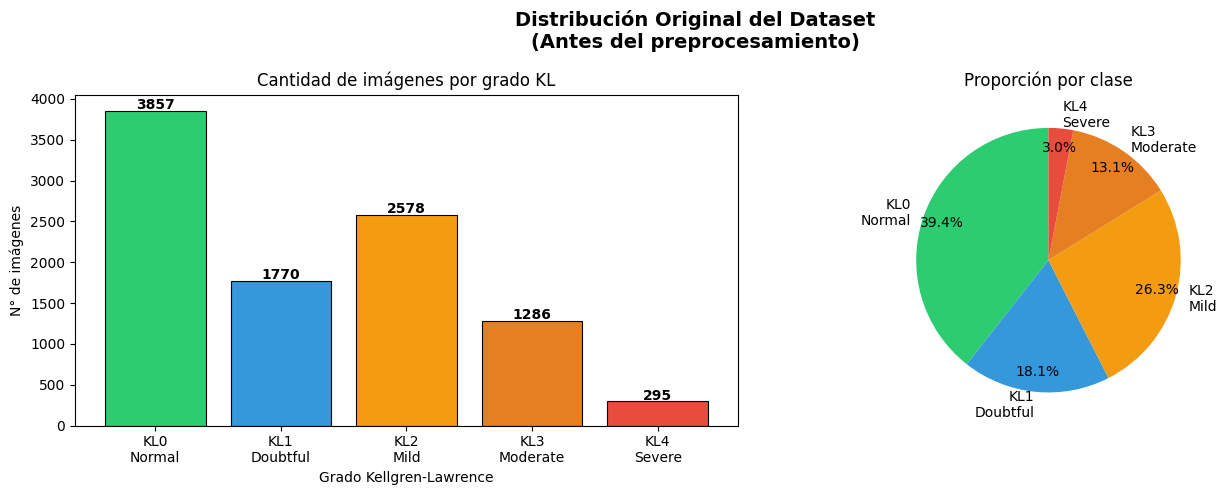


⚠️  OBSERVACIÓN: El dataset está DESBALANCEADO.
   Clase mayoría (Grado 0 Normal): 3857 imgs
   Clase minoría (Grado 4 Severe): 295 imgs
   Ratio de desbalance: 13.1x


In [8]:
# ─────────────────────────────────────────────────────────────
# CELDA 3 — EXPLORACIÓN DEL DATASET ORIGINAL
#            Ver cuántas imágenes hay por clase y por split
# ─────────────────────────────────────────────────────────────

DATASET_PATH = Path('/content/dataset_original')

# Detectar qué carpetas/splits existen
print("📁 Estructura del dataset descargado:")
for item in sorted(DATASET_PATH.iterdir()):
    print(f"   {item.name}/")
    if item.is_dir():
        for sub in sorted(item.iterdir()):
            if sub.is_dir():
                count = len(list(sub.glob('*.jpg')) + list(sub.glob('*.png')))
                label = KL_LABELS.get(sub.name, sub.name)
                print(f"      Grado {sub.name} ({label}): {count} imágenes")

# Contar totales por clase (uniendo todos los splits)
print("\n📊 Conteo TOTAL por clase (todos los splits unidos):")
total_por_clase = defaultdict(int)

for split_dir in DATASET_PATH.iterdir():
    if split_dir.is_dir():
        for class_dir in split_dir.iterdir():
            if class_dir.is_dir() and class_dir.name in CLASSES:
                imgs = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
                total_por_clase[class_dir.name] += len(imgs)

for cls in CLASSES:
    label = KL_LABELS[cls]
    n = total_por_clase[cls]
    print(f"   Grado {cls} ({label}): {n} imágenes")

total = sum(total_por_clase.values())
print(f"\n   TOTAL GENERAL: {total} imágenes")

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución Original del Dataset\n(Antes del preprocesamiento)',
             fontsize=14, fontweight='bold')

counts = [total_por_clase[c] for c in CLASSES]
labels_plot = [f"KL{c}\n{KL_LABELS[c]}" for c in CLASSES]

# Barras
axes[0].bar(labels_plot, counts, color=COLORS, edgecolor='black', linewidth=0.8)
axes[0].set_title('Cantidad de imágenes por grado KL')
axes[0].set_ylabel('N° de imágenes')
axes[0].set_xlabel('Grado Kellgren-Lawrence')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Torta
axes[1].pie(counts, labels=labels_plot, colors=COLORS, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[1].set_title('Proporción por clase')

plt.tight_layout()
plt.savefig('/content/01_distribucion_original.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️  OBSERVACIÓN: El dataset está DESBALANCEADO.")
print(f"   Clase mayoría (Grado 0 Normal): {total_por_clase['0']} imgs")
print(f"   Clase minoría (Grado 4 Severe): {total_por_clase['4']} imgs")
print(f"   Ratio de desbalance: {total_por_clase['0']/total_por_clase['4']:.1f}x")

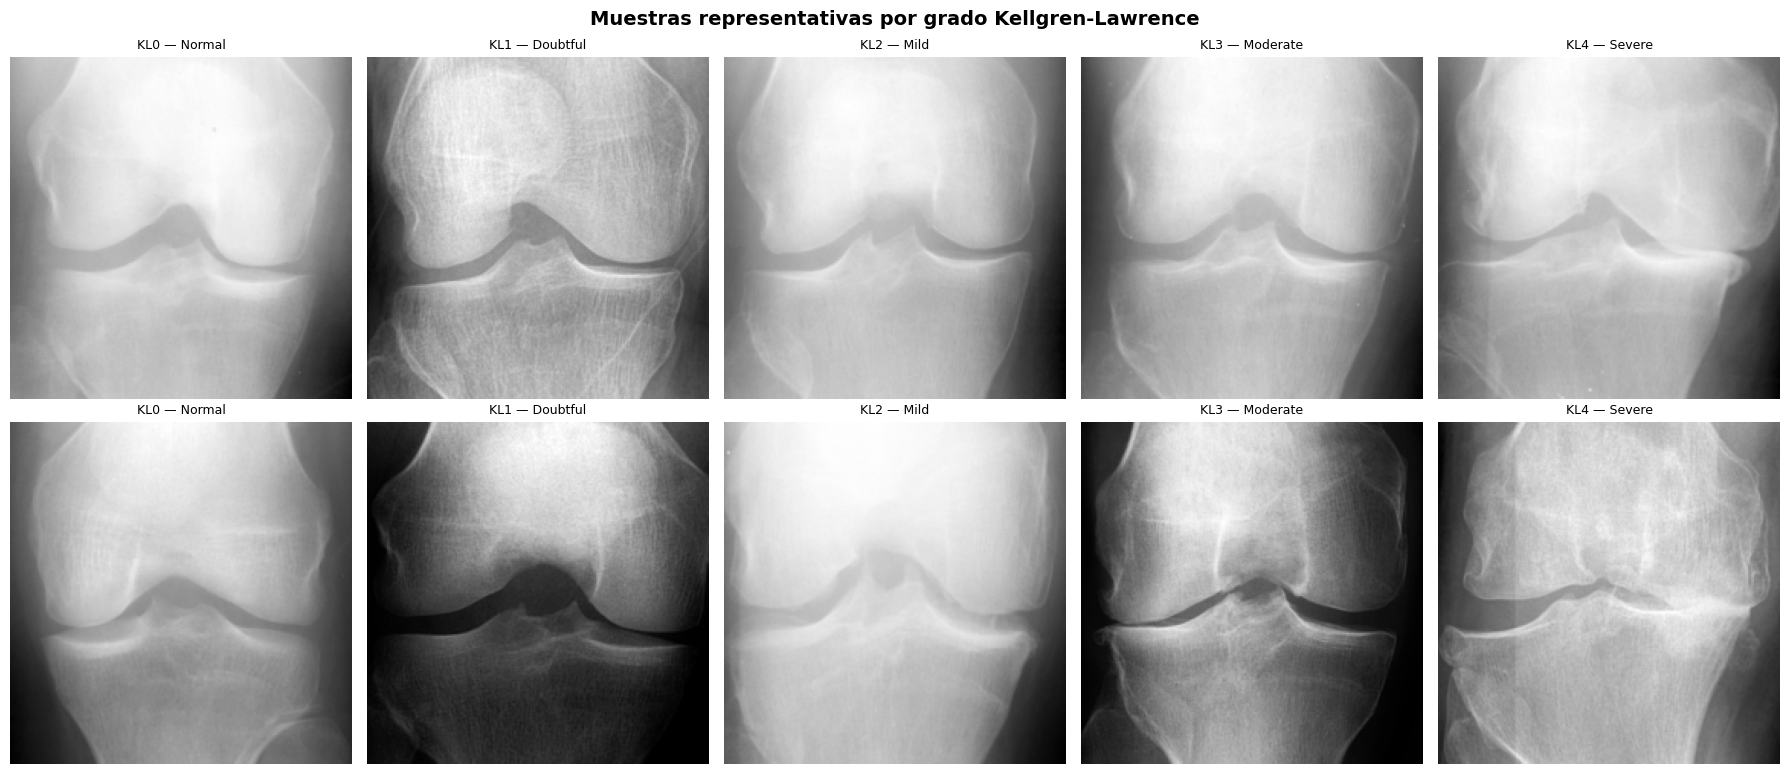

✅ Inspección visual completada.


In [9]:
# ─────────────────────────────────────────────────────────────
# CELDA 4 — INSPECCIÓN VISUAL DE MUESTRAS
#            Ver ejemplos de imágenes de cada grado KL
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Muestras representativas por grado Kellgren-Lawrence',
             fontsize=14, fontweight='bold')

for col, cls in enumerate(CLASSES):
    samples = []
    for split_dir in DATASET_PATH.iterdir():
        if split_dir.is_dir():
            class_dir = split_dir / cls
            if class_dir.exists():
                samples += list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))

    # Mostrar 2 ejemplos por clase
    chosen = random.sample(samples, min(2, len(samples)))
    for row, img_path in enumerate(chosen):
        img = Image.open(img_path).convert('L')  # escala de grises
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f"KL{cls} — {KL_LABELS[cls]}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('/content/02_muestras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Inspección visual completada.")

In [10]:
# ─────────────────────────────────────────────────────────────
# CELDA 5 — RECOLECCIÓN Y UNIFICACIÓN
#            Juntar todas las imágenes en una lista única
#            con su etiqueta, ignorando los splits originales
# ─────────────────────────────────────────────────────────────

all_images = []  # lista de (ruta, clase)

for split_dir in DATASET_PATH.iterdir():
    if split_dir.is_dir():
        for class_dir in split_dir.iterdir():
            if class_dir.is_dir() and class_dir.name in CLASSES:
                for img_path in class_dir.glob('*.jpg'):
                    all_images.append((str(img_path), class_dir.name))
                for img_path in class_dir.glob('*.png'):
                    all_images.append((str(img_path), class_dir.name))

df_all = pd.DataFrame(all_images, columns=['ruta', 'clase'])
df_all = df_all.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle

print(f"✅ Total de imágenes unificadas: {len(df_all)}")
print(f"\nDistribución:")
print(df_all['clase'].value_counts().sort_index())

✅ Total de imágenes unificadas: 9786

Distribución:
clase
0    3857
1    1770
2    2578
3    1286
4     295
Name: count, dtype: int64



DIVISIÓN ESTRATIFICADA 70 / 20 / 10

¿Qué es estratificación?
Significa que cada subconjunto (train, val, test) mantiene
la MISMA proporción de cada clase que el dataset completo.
Ejemplo: si el 3% son Grado 4, entonces el 3% de train,
el 3% de val y el 3% de test también serán Grado 4.
Esto evita que un split tenga pocas imágenes de una clase.


📐 DIVISIÓN ESTRATIFICADA 70 / 20 / 10
  Train: 6851 imgs (70.0%)
  Val:   1956 imgs  (20.0%)
  Test:  979 imgs (10.0%)
  TOTAL: 9786 imgs

📊 Distribución por clase en cada split:
Clase           Train      Val     Test   %Train    %Val   %Test
------------------------------------------------------------
KL0 Normal         2700      771      386    70.0%   20.0%   10.0%
KL1 Doubtful       1239      354      177    70.0%   20.0%   10.0%
KL2 Mild           1805      515      258    70.0%   20.0%   10.0%
KL3 Moderate        900      257      129    70.0%   20.0%   10.0%
KL4 Severe          207       59       29    70.2%   20.0%    9.8%


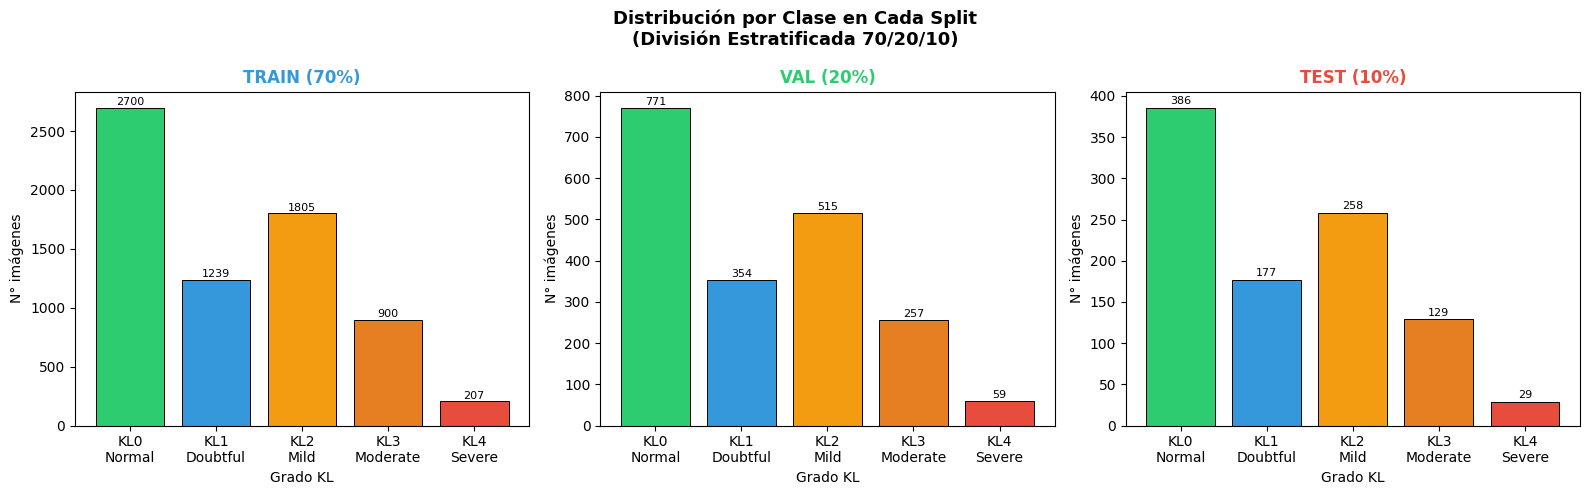


✅ División estratificada completada y verificada.


In [11]:
# Paso 1: Separar 10% para TEST (estratificado)
df_trainval, df_test = train_test_split(
    df_all,
    test_size=0.10,
    stratify=df_all['clase'],
    random_state=SEED
)

# Paso 2: Del 90% restante, separar ~22.2% para VAL
# (0.222 * 0.90 ≈ 0.20 del total → VAL = 20%)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.222,
    stratify=df_trainval['clase'],
    random_state=SEED
)

print("=" * 50)
print("📐 DIVISIÓN ESTRATIFICADA 70 / 20 / 10")
print("=" * 50)
print(f"  Train: {len(df_train)} imgs ({len(df_train)/len(df_all)*100:.1f}%)")
print(f"  Val:   {len(df_val)} imgs  ({len(df_val)/len(df_all)*100:.1f}%)")
print(f"  Test:  {len(df_test)} imgs ({len(df_test)/len(df_all)*100:.1f}%)")
print(f"  TOTAL: {len(df_train)+len(df_val)+len(df_test)} imgs")

# Verificar proporción por clase en cada split
print("\n📊 Distribución por clase en cada split:")
print(f"{'Clase':<12} {'Train':>8} {'Val':>8} {'Test':>8} {'%Train':>8} {'%Val':>7} {'%Test':>7}")
print("-" * 60)
for cls in CLASSES:
    tr = (df_train['clase'] == cls).sum()
    va = (df_val['clase']   == cls).sum()
    te = (df_test['clase']  == cls).sum()
    tot_cls = total_por_clase[cls]
    print(f"KL{cls} {KL_LABELS[cls]:<10} {tr:>8} {va:>8} {te:>8} "
          f"{tr/tot_cls*100:>7.1f}% {va/tot_cls*100:>6.1f}% {te/tot_cls*100:>6.1f}%")

# Visualizar comparación de distribución entre splits
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución por Clase en Cada Split\n(División Estratificada 70/20/10)',
             fontsize=13, fontweight='bold')

splits_data = [
    (df_train, 'TRAIN (70%)', '#3498db'),
    (df_val,   'VAL (20%)',   '#2ecc71'),
    (df_test,  'TEST (10%)',  '#e74c3c')
]

for ax, (df_split, title, color) in zip(axes, splits_data):
    counts_split = [( df_split['clase'] == c).sum() for c in CLASSES]
    bars = ax.bar(labels_plot, counts_split, color=COLORS, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold', color=color, fontsize=12)
    ax.set_ylabel('N° imágenes')
    ax.set_xlabel('Grado KL')
    for bar, val in zip(bars, counts_split):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/03_division_estratificada.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ División estratificada completada y verificada.")


PREPROCESAMIENTO BASE

Normalización y redimensionamiento

Se crea la carpeta /content/dataset_procesado/

🔄 Preprocesando imágenes...
   Tamaño destino: 224×224 px
   Mejora de contraste: CLAHE

   ✅ train : 6851 imágenes preprocesadas
   ✅ val   : 1956 imágenes preprocesadas
   ✅ test  : 979 imágenes preprocesadas

   Total procesadas: 9786

📸 Comparando imagen original vs preprocesada...


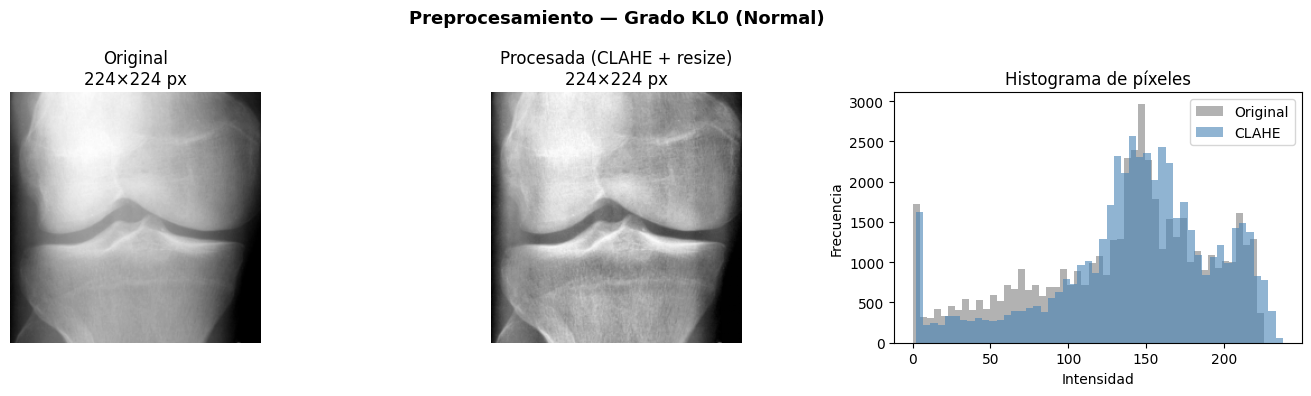

In [12]:
# Configuración
IMG_SIZE    = (224, 224)   # estándar para EfficientNet, ResNet, VGG
OUTPUT_PATH = Path('/content/dataset_procesado')

def preprocesar_imagen(ruta_origen, ruta_destino, img_size=IMG_SIZE):
    """
    Pipeline de preprocesamiento para una imagen radiográfica:
    1. Cargar en escala de grises
    2. Redimensionar a tamaño fijo manteniendo aspecto (con padding)
    3. Ecualización de histograma CLAHE (mejora contraste en radiografías)
    4. Normalizar píxeles a [0, 255] uint8
    5. Guardar como PNG sin pérdida
    """
    img = cv2.imread(str(ruta_origen), cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"  ⚠️  No se pudo leer: {ruta_origen}")
        return False

    # Redimensionar con padding para mantener aspecto
    h, w = img.shape
    scale = min(img_size[0]/h, img_size[1]/w)
    new_h, new_w = int(h*scale), int(w*scale)
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Padding centrado
    pad_h = (img_size[0] - new_h) // 2
    pad_w = (img_size[1] - new_w) // 2
    img_padded = cv2.copyMakeBorder(img_resized, pad_h, img_size[0]-new_h-pad_h,
                                     pad_w, img_size[1]-new_w-pad_w,
                                     cv2.BORDER_CONSTANT, value=0)

    # CLAHE — mejora el contraste local (clave para radiografías)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_padded)

    # Guardar
    os.makedirs(ruta_destino.parent, exist_ok=True)
    cv2.imwrite(str(ruta_destino), img_clahe)
    return True

# Procesar los 3 splits
split_dfs = [
    (df_train, 'train'),
    (df_val,   'val'),
    (df_test,  'test')
]

print("🔄 Preprocesando imágenes...")
print(f"   Tamaño destino: {IMG_SIZE[0]}×{IMG_SIZE[1]} px")
print(f"   Mejora de contraste: CLAHE")
print()

total_procesadas = 0
errores = 0

for df_split, split_name in split_dfs:
    ok = 0
    for _, row in df_split.iterrows():
        ruta_origen = Path(row['ruta'])
        ruta_destino = OUTPUT_PATH / split_name / row['clase'] / ruta_origen.name
        if preprocesar_imagen(ruta_origen, ruta_destino):
            ok += 1
        else:
            errores += 1
    total_procesadas += ok
    print(f"   ✅ {split_name:<6}: {ok} imágenes preprocesadas")

print(f"\n   Total procesadas: {total_procesadas}")
if errores:
    print(f"   ⚠️  Errores: {errores}")

# Comparar visual: original vs preprocesada
print("\n📸 Comparando imagen original vs preprocesada...")
sample_path = df_train.iloc[0]['ruta']
sample_class = df_train.iloc[0]['clase']
sample_name  = Path(sample_path).name
proc_path = OUTPUT_PATH / 'train' / sample_class / sample_name

orig = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
proc = cv2.imread(str(proc_path), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Preprocesamiento — Grado KL{sample_class} ({KL_LABELS[sample_class]})',
             fontsize=13, fontweight='bold')

axes[0].imshow(orig, cmap='gray')
axes[0].set_title(f'Original\n{orig.shape[1]}×{orig.shape[0]} px')
axes[0].axis('off')

axes[1].imshow(proc, cmap='gray')
axes[1].set_title(f'Procesada (CLAHE + resize)\n{IMG_SIZE[1]}×{IMG_SIZE[0]} px')
axes[1].axis('off')

# Histogramas
axes[2].hist(orig.ravel(), bins=50, alpha=0.6, color='gray', label='Original')
axes[2].hist(proc.ravel(), bins=50, alpha=0.6, color='steelblue', label='CLAHE')
axes[2].set_title('Histograma de píxeles')
axes[2].set_xlabel('Intensidad')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/04_comparacion_preprocesamiento.png', dpi=150, bbox_inches='tight')
plt.show()

 DATA AUGMENTATION

-Solo se aplica al conjunto TRAIN

-Las clases minoritarias reciben más aumentos

In [13]:
def augmentar_imagen(img, seed=None):
    """
    Aplica una transformación aleatoria clínicamente válida para radiografías.
    NO se usan transformaciones que distorsionen anatomía (no shear extremo, no color jitter).
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    h, w = img.shape[:2]
    transformaciones = []

    # 1. Rotación leve (±10°)
    angle = random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    transformaciones.append(f'rot({angle:.1f}°)')

    # 2. Flip horizontal (50% de probabilidad)
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        transformaciones.append('flip_H')

    # 3. Ajuste de brillo/contraste
    alpha = random.uniform(0.85, 1.15)  # contraste
    beta  = random.randint(-15, 15)     # brillo
    img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)
    transformaciones.append(f'bright(α={alpha:.2f},β={beta})')

    # 4. Zoom leve (±5%)
    zoom = random.uniform(0.95, 1.05)
    new_h, new_w = int(h*zoom), int(w*zoom)
    img_zoom = cv2.resize(img, (new_w, new_h))
    if zoom > 1:
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        img = img_zoom[start_h:start_h+h, start_w:start_w+w]
    else:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        img = cv2.copyMakeBorder(img_zoom, pad_h, h-new_h-pad_h,
                                  pad_w, w-new_w-pad_w, cv2.BORDER_REFLECT)
    transformaciones.append(f'zoom({zoom:.2f}x)')

    return img, transformaciones

Estrategia de balanceo:

Se aumentarán las clases con menos imágenes para llevarlas a un nivel más cercano a la clase mayoritaria en TRAIN.

TARGET: equilibrar hacia ~1500 imágenes por clase en train.

🔄 Aplicando Data Augmentation al conjunto TRAIN...
   Objetivo por clase: 1500 imágenes

   KL0 (Normal    ): 2700 originales → +0 aug = 2700 total
   KL1 (Doubtful  ): 1239 originales → +261 aug = 1500 total
   KL2 (Mild      ): 1805 originales → +0 aug = 1805 total
   KL3 (Moderate  ): 900 originales → +600 aug = 1500 total
   KL4 (Severe    ): 207 originales → +1293 aug = 1500 total

📊 Comparando antes y después del Data Augmentation:


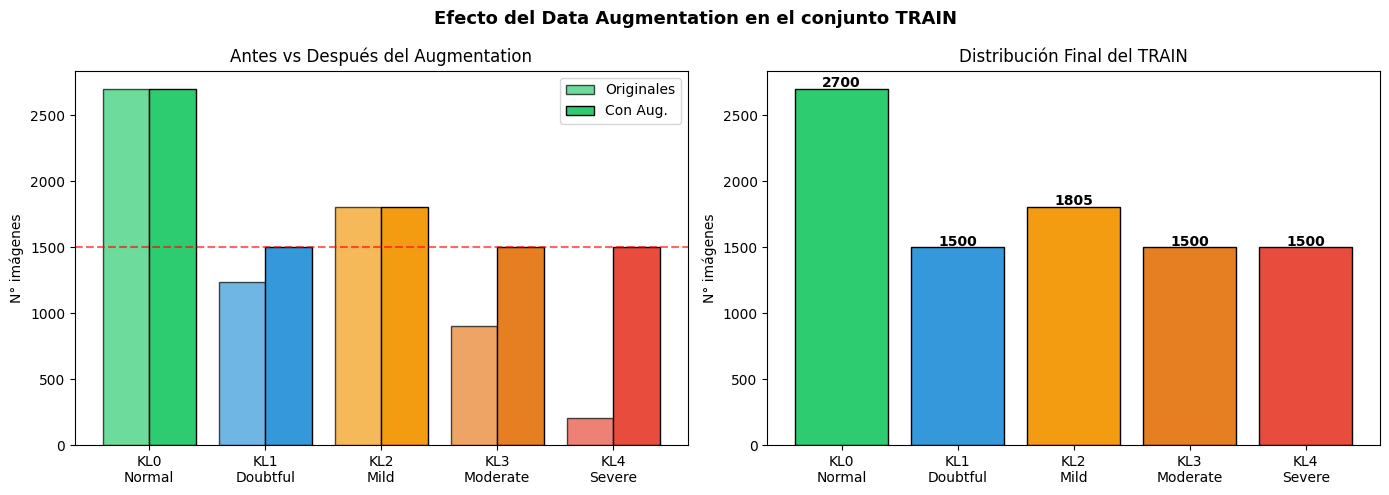


📸 Ejemplos de transformaciones de Data Augmentation:


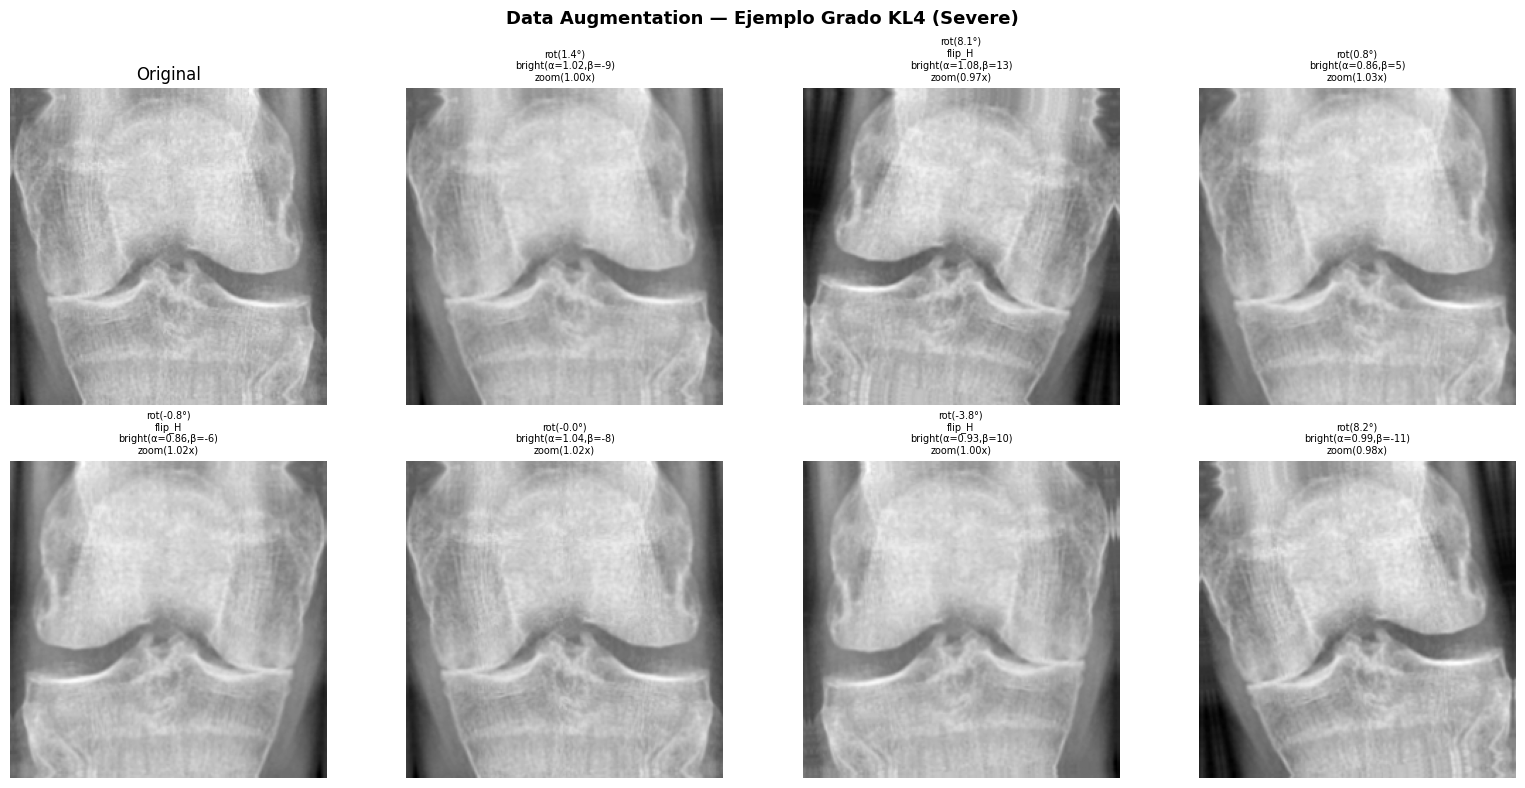

In [14]:
TARGET_PER_CLASS = 1500  # imágenes objetivo por clase en train

print("🔄 Aplicando Data Augmentation al conjunto TRAIN...")
print(f"   Objetivo por clase: {TARGET_PER_CLASS} imágenes")
print()

AUG_PATH = Path('/content/dataset_aumentado')

# Primero copiar las imágenes originales de train
for cls in CLASSES:
    src_dir  = OUTPUT_PATH / 'train' / cls
    dst_dir  = AUG_PATH / 'train' / cls
    os.makedirs(dst_dir, exist_ok=True)
    for img_file in src_dir.glob('*.png'):
        shutil.copy2(img_file, dst_dir / img_file.name)

# Copiar val y test sin augmentation
for split in ['val', 'test']:
    for cls in CLASSES:
        src = OUTPUT_PATH / split / cls
        dst = AUG_PATH / split / cls
        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)

# Generar imágenes aumentadas para clases que necesitan
resumen_aug = {}
for cls in CLASSES:
    train_dir = AUG_PATH / 'train' / cls
    existing  = list(train_dir.glob('*.png'))
    n_existing = len(existing)
    n_needed   = max(0, TARGET_PER_CLASS - n_existing)

    print(f"   KL{cls} ({KL_LABELS[cls]:<10}): {n_existing} originales → ", end='')

    aug_count = 0
    if n_needed > 0:
        for i in range(n_needed):
            # Elegir imagen base aleatoria
            base_img_path = random.choice(existing)
            base_img = cv2.imread(str(base_img_path), cv2.IMREAD_GRAYSCALE)
            aug_img, _ = augmentar_imagen(base_img, seed=SEED+i)
            out_name = f"aug_{cls}_{i:04d}.png"
            cv2.imwrite(str(train_dir / out_name), aug_img)
            aug_count += 1

    total_final = len(list(train_dir.glob('*.png')))
    resumen_aug[cls] = {'original': n_existing, 'aumentadas': aug_count, 'total': total_final}
    print(f"+{aug_count} aug = {total_final} total")

# Visualizar resultado del balanceo
print("\n📊 Comparando antes y después del Data Augmentation:")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efecto del Data Augmentation en el conjunto TRAIN',
             fontsize=13, fontweight='bold')

orig_counts = [resumen_aug[c]['original']   for c in CLASSES]
aug_counts  = [resumen_aug[c]['aumentadas'] for c in CLASSES]
total_final = [resumen_aug[c]['total']       for c in CLASSES]

x = np.arange(len(CLASSES))
w = 0.4

axes[0].bar(x - w/2, orig_counts, w, label='Originales', color=COLORS, alpha=0.7, edgecolor='black')
axes[0].bar(x + w/2, total_final, w, label='Con Aug.',   color=COLORS, alpha=1.0, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_plot)
axes[0].set_ylabel('N° imágenes')
axes[0].set_title('Antes vs Después del Augmentation')
axes[0].legend()
axes[0].axhline(y=TARGET_PER_CLASS, color='red', linestyle='--', alpha=0.6, label=f'Target {TARGET_PER_CLASS}')

axes[1].bar(labels_plot, total_final, color=COLORS, edgecolor='black')
axes[1].set_title('Distribución Final del TRAIN')
axes[1].set_ylabel('N° imágenes')
for i, v in enumerate(total_final):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/05_resultado_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar ejemplos de augmentation
print("\n📸 Ejemplos de transformaciones de Data Augmentation:")
sample_path = list((AUG_PATH / 'train' / '4').glob('*.png'))[0]
base = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation — Ejemplo Grado KL4 (Severe)', fontsize=13, fontweight='bold')

axes[0,0].imshow(base, cmap='gray')
axes[0,0].set_title('Original')
axes[0,0].axis('off')

for idx in range(1, 8):
    aug, transfs = augmentar_imagen(base, seed=idx*10)
    r, c = divmod(idx, 4)
    axes[r, c].imshow(aug, cmap='gray')
    axes[r, c].set_title('\n'.join(transfs), fontsize=7)
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig('/content/06_ejemplos_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

VERIFICACIÓN FINAL DEL DATASET PROCESADO

In [15]:
print("=" * 55)
print("  ✅  RESUMEN FINAL — DATASET LISTO PARA ENTRENAMIENTO")
print("=" * 55)

for split_name in ['train', 'val', 'test']:
    split_dir = AUG_PATH / split_name
    print(f"\n  📁 {split_name.upper()}/")
    split_total = 0
    for cls in CLASSES:
        cls_dir = split_dir / cls
        if cls_dir.exists():
            n = len(list(cls_dir.glob('*.png')))
            split_total += n
            print(f"     KL{cls} ({KL_LABELS[cls]:<10}): {n:>5} imágenes")
    print(f"     {'SUBTOTAL':<17}: {split_total:>5} imágenes")

print(f"\n  📐 Tamaño de imagen: {IMG_SIZE[0]}×{IMG_SIZE[1]} px")
print(f"  🎨 Canales: 1 (escala de grises) → convertir a 3 canales en entrenamiento")
print(f"  📂 Ruta del dataset: /content/dataset_aumentado/")
print()
print("  PRÓXIMO PASO → Objetivo Específico 2:")
print("  Entrenar y comparar modelos CNN, SVM y Random Forest")

# Guardar rutas en un diccionario para usar en el siguiente notebook
import json
dataset_info = {
    "dataset_path": str(AUG_PATH),
    "img_size": list(IMG_SIZE),
    "classes": CLASSES,
    "kl_labels": KL_LABELS,
    "splits": ["train", "val", "test"],
    "seed": SEED
}
with open('/content/dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print("\n  💾 Configuración guardada en /content/dataset_info.json")
print("     (úsala en el siguiente notebook para cargar el dataset)")

  ✅  RESUMEN FINAL — DATASET LISTO PARA ENTRENAMIENTO

  📁 TRAIN/
     KL0 (Normal    ):  2700 imágenes
     KL1 (Doubtful  ):  1500 imágenes
     KL2 (Mild      ):  1805 imágenes
     KL3 (Moderate  ):  1500 imágenes
     KL4 (Severe    ):  1500 imágenes
     SUBTOTAL         :  9005 imágenes

  📁 VAL/
     KL0 (Normal    ):   771 imágenes
     KL1 (Doubtful  ):   354 imágenes
     KL2 (Mild      ):   515 imágenes
     KL3 (Moderate  ):   257 imágenes
     KL4 (Severe    ):    59 imágenes
     SUBTOTAL         :  1956 imágenes

  📁 TEST/
     KL0 (Normal    ):   386 imágenes
     KL1 (Doubtful  ):   177 imágenes
     KL2 (Mild      ):   258 imágenes
     KL3 (Moderate  ):   129 imágenes
     KL4 (Severe    ):    29 imágenes
     SUBTOTAL         :   979 imágenes

  📐 Tamaño de imagen: 224×224 px
  🎨 Canales: 1 (escala de grises) → convertir a 3 canales en entrenamiento
  📂 Ruta del dataset: /content/dataset_aumentado/

  PRÓXIMO PASO → Objetivo Específico 2:
  Entrenar y comparar mode

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Crear carpeta en tu Drive
import os
os.makedirs('/content/drive/MyDrive/tesis_OA', exist_ok=True)

# Copiar todo lo procesado
print("Copiando dataset_procesado...")
shutil.copytree('/content/dataset_procesado',
                '/content/drive/MyDrive/tesis_OA/dataset_procesado',
                dirs_exist_ok=True)

print("Copiando dataset_aumentado...")
shutil.copytree('/content/dataset_aumentado',
                '/content/drive/MyDrive/tesis_OA/dataset_aumentado',
                dirs_exist_ok=True)

print("Copiando imágenes de gráficas...")
import glob
for f in glob.glob('/content/*.png'):
    shutil.copy(f, '/content/drive/MyDrive/tesis_OA/')

print("✅ Todo guardado en Google Drive > tesis_OA/")

Mounted at /content/drive
Copiando dataset_procesado...
Copiando dataset_aumentado...
Copiando imágenes de gráficas...
✅ Todo guardado en Google Drive > tesis_OA/


In [17]:
from pathlib import Path

AUG_PATH = Path('/content/dataset_aumentado')

print("📊 Conteo actual por split y clase:")
print(f"{'Split':<8} {'KL0':>6} {'KL1':>6} {'KL2':>6} {'KL3':>6} {'KL4':>6} {'TOTAL':>8}")
print("-" * 50)

for split in ['train', 'val', 'test']:
    counts = []
    for cls in ['0','1','2','3','4']:
        cls_dir = AUG_PATH / split / cls
        n = len(list(cls_dir.glob('*.png'))) if cls_dir.exists() else 0
        counts.append(n)
    print(f"{split:<8} {counts[0]:>6} {counts[1]:>6} {counts[2]:>6} {counts[3]:>6} {counts[4]:>6} {sum(counts):>8}")

📊 Conteo actual por split y clase:
Split       KL0    KL1    KL2    KL3    KL4    TOTAL
--------------------------------------------------
train      2700   1500   1805   1500   1500     9005
val         771    354    515    257     59     1956
test        386    177    258    129     29      979


In [18]:
from pathlib import Path

AUG_PATH = Path('/content/drive/MyDrive/tesis_OA/dataset_aumentado')

for split in ['train', 'val', 'test']:
    print(f"\n📁 {split.upper()}/")
    for cls in ['0','1','2','3','4']:
        cls_dir = AUG_PATH / split / cls
        if cls_dir.exists():
            n = len(list(cls_dir.glob('*.png')))
            print(f"   KL{cls}: {n} imágenes")
        else:
            print(f"   KL{cls}: ❌ carpeta no existe")


📁 TRAIN/
   KL0: 2700 imágenes
   KL1: 1500 imágenes
   KL2: 1805 imágenes
   KL3: 1500 imágenes
   KL4: 1500 imágenes

📁 VAL/
   KL0: 771 imágenes
   KL1: 354 imágenes
   KL2: 515 imágenes
   KL3: 257 imágenes
   KL4: 59 imágenes

📁 TEST/
   KL0: 386 imágenes
   KL1: 177 imágenes
   KL2: 258 imágenes
   KL3: 129 imágenes
   KL4: 29 imágenes


PARTE 2

In [1]:
# ─────────────────────────────────────────────────────────────
# Instalaciones
# ─────────────────────────────────────────────────────────────

!pip install torch torchvision scikit-learn opencv-python-headless \
 matplotlib seaborn pandas numpy tqdm -q

print("✅ Librerías listas.")

✅ Librerías listas.


Importaciones y configuración global

In [3]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Scikit-learn
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, recall_score, precision_score)
from sklearn.decomposition import PCA

import cv2

# ── Reproducibilidad ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Configuración ──
DATASET_PATH = Path('/content/drive/MyDrive/tesis_OA/dataset_aumentado')
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
NUM_EPOCHS   = 20          # aumenta a 30-50 si tienes tiempo
NUM_CLASSES  = 5
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASSES   = ['0', '1', '2', '3', '4']
KL_LABELS = {
    '0': 'Normal',
    '1': 'Doubtful',
    '2': 'Mild',
    '3': 'Moderate',
    '4': 'Severe'
}
CLASS_NAMES = [f"KL{c} {KL_LABELS[c]}" for c in CLASSES]
COLORS      = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

print(f"✅ Dispositivo: {DEVICE}")
print(f"   GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Dispositivo: cuda
   GPU disponible: True
   GPU: Tesla T4


Dataset personalizado para PyTorch

In [4]:
class KneeOADataset(Dataset):
    """
    Carga imágenes desde la estructura:
    dataset_aumentado/
        train/ 0/ 1/ 2/ 3/ 4/
        val/   0/ 1/ 2/ 3/ 4/
        test/  0/ 1/ 2/ 3/ 4/
    """
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir  = Path(root_dir) / split
        self.transform = transform
        self.samples   = []  # lista de (ruta, etiqueta_int)

        for cls_idx, cls in enumerate(CLASSES):
            cls_dir = self.root_dir / cls
            if cls_dir.exists():
                for img_path in cls_dir.glob('*.png'):
                    self.samples.append((str(img_path), cls_idx))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # Cargar en escala de grises y convertir a RGB (3 canales)
        # porque EfficientNet espera 3 canales
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        if self.transform:
            from PIL import Image as PILImage
            img = PILImage.fromarray(img)
            img = self.transform(img)

        return img, label

# Transformaciones
# Train: con augmentation ligera adicional
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # valores ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Val / Test: sin augmentation
val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Crear datasets
train_dataset = KneeOADataset(DATASET_PATH, 'train', train_transform)
val_dataset   = KneeOADataset(DATASET_PATH, 'val',   val_transform)
test_dataset  = KneeOADataset(DATASET_PATH, 'test',  val_transform)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Datasets cargados:")
print(f"   Train: {len(train_dataset)} imágenes")
print(f"   Val:   {len(val_dataset)} imágenes")
print(f"   Test:  {len(test_dataset)} imágenes")


✅ Datasets cargados:
   Train: 9005 imágenes
   Val:   1956 imágenes
   Test:  979 imágenes


FUNCIONES DE EVALUACIÓN (usadas por los 3 modelos)

In [8]:
def calcular_metricas(y_true, y_pred, y_prob=None, nombre_modelo='Modelo'):
    """
    Calcula todas las métricas requeridas por la tesis:
    Accuracy, Precision, Recall, F1-Score, AUC, Matriz de confusión
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # AUC multiclase (requiere probabilidades)
    auc = None
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
        except:
            auc = None

    print(f"\n{'='*50}")
    print(f"  📊 MÉTRICAS — {nombre_modelo}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    if auc:
        print(f"  AUC (OvR) : {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=CLASS_NAMES, zero_division=0))

    return {'modelo': nombre_modelo, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc}


def graficar_confusion(y_true, y_pred, nombre_modelo, save_path):
    """Matriz de confusión normalizada y sin normalizar"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Matriz de Confusión — {nombre_modelo}',
                 fontsize=13, fontweight='bold')

    for ax, normalize, title in zip(axes,
                                     [None, 'true'],
                                     ['Valores absolutos', 'Normalizada (%)']):
        cm = confusion_matrix(y_true, y_pred, normalize=normalize)
        fmt = '.2f' if normalize else 'd'
        sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    linewidths=0.5)
        ax.set_title(title)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def graficar_roc(y_true, y_prob, nombre_modelo, save_path):
    """Curva ROC one-vs-rest para cada clase"""
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_cls = roc_auc_score(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'KL{cls} {KL_LABELS[cls]} (AUC={auc_cls:.3f})')

    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {nombre_modelo}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()



MODELO 1: CNN con EfficientNet-B0 (Transfer Learning)

🧠 MODELO 1: EfficientNet-B0 con Transfer Learning
──────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s]


   Total parámetros:     4,336,769
   Parámetros entrenables: 329,221

   Entrenando por 20 épocas...
   Época   1/20 | Loss: 1.2896/1.3334 | Acc: 42.45%/44.94%
   Época   5/20 | Loss: 1.1809/1.2839 | Acc: 47.84%/45.55%
   Época  10/20 | Loss: 1.1465/1.2688 | Acc: 50.37%/48.62%
   Época  15/20 | Loss: 1.1350/1.2564 | Acc: 50.42%/48.93%
   Época  20/20 | Loss: 1.1107/1.2280 | Acc: 50.92%/49.69%

   ✅ Entrenamiento CNN: 58.5 min
   Mejor Val Accuracy: 49.74%


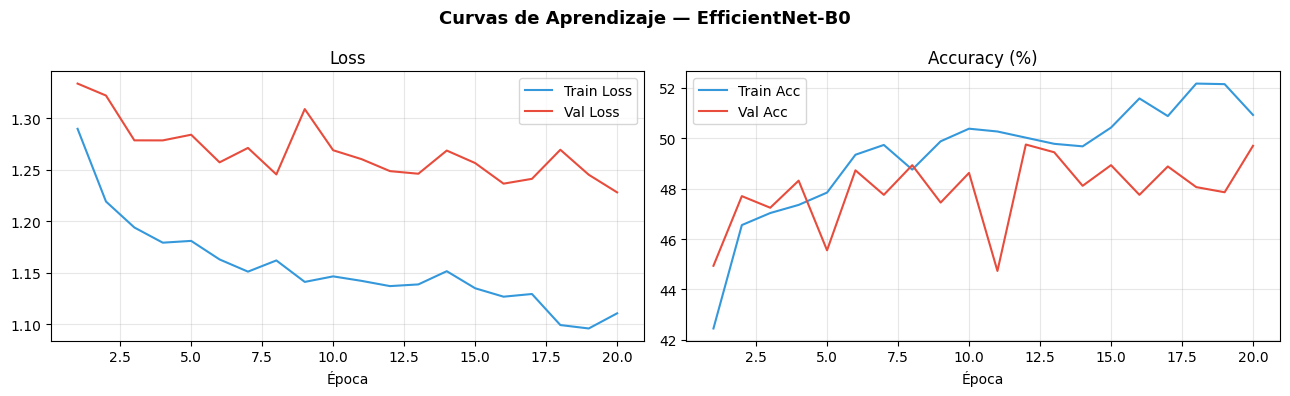

In [9]:
print("🧠 MODELO 1: EfficientNet-B0 con Transfer Learning")
print("─" * 50)

# Cargar EfficientNet preentrenado en ImageNet
cnn_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Congelar todas las capas excepto el clasificador final
for param in cnn_model.parameters():
    param.requires_grad = False

# Reemplazar el clasificador para 5 clases
in_features = cnn_model.classifier[1].in_features
cnn_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
)

cnn_model = cnn_model.to(DEVICE)

# Calcular parámetros entrenables
total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"   Total parámetros:     {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

# Función de pérdida y optimizador
# class_weights para manejar desbalance
class_counts = np.array([len(list((DATASET_PATH/'train'/c).glob('*.png')))
                          for c in CLASSES], dtype=np.float32)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(cnn_model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                   factor=0.5, patience=3)

# ── Entrenamiento ──
cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = '/content/best_cnn_model.pth'
t0_cnn = time.time()

print(f"\n   Entrenando por {NUM_EPOCHS} épocas...")

for epoch in range(NUM_EPOCHS):
    # ── TRAIN ──
    cnn_model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # ── VALIDACIÓN ──
    cnn_model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = cnn_model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    t_acc = train_correct / len(train_dataset)
    v_acc = val_correct   / len(val_dataset)
    t_loss = train_loss   / len(train_dataset)
    v_loss = val_loss     / len(val_dataset)

    cnn_history['train_acc'].append(t_acc)
    cnn_history['val_acc'].append(v_acc)
    cnn_history['train_loss'].append(t_loss)
    cnn_history['val_loss'].append(v_loss)

    scheduler.step(v_acc)

    # Guardar mejor modelo
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(cnn_model.state_dict(), best_model_path)

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"   Época {epoch+1:>3}/{NUM_EPOCHS} | "
              f"Loss: {t_loss:.4f}/{v_loss:.4f} | "
              f"Acc: {t_acc*100:.2f}%/{v_acc*100:.2f}%")

cnn_time = time.time() - t0_cnn
print(f"\n   ✅ Entrenamiento CNN: {cnn_time/60:.1f} min")
print(f"   Mejor Val Accuracy: {best_val_acc*100:.2f}%")

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Curvas de Aprendizaje — EfficientNet-B0', fontsize=13, fontweight='bold')
epochs_x = range(1, NUM_EPOCHS+1)

axes[0].plot(epochs_x, cnn_history['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(epochs_x, cnn_history['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in cnn_history['train_acc']], label='Train Acc', color='#3498db')
axes[1].plot(epochs_x, [a*100 for a in cnn_history['val_acc']],   label='Val Acc',   color='#e74c3c')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/07_cnn_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

Fine-Tuning: descongelar capas del backbone

🔓 Iniciando Fine-Tuning de EfficientNet-B0...
──────────────────────────────────────────────────
   Parámetros entrenables ahora: 3,484,961
   Entrenando 20 épocas de fine-tuning...
   Época   1/20 | Loss: 1.0447/1.0917 | Acc: 54.25%/53.27%
   Época   5/20 | Loss: 0.7298/0.9312 | Acc: 67.77%/61.09%
   Época  10/20 | Loss: 0.6205/0.9276 | Acc: 72.45%/63.85%
   Época  15/20 | Loss: 0.5577/0.9336 | Acc: 74.75%/64.98%
   Época  20/20 | Loss: 0.4655/0.9482 | Acc: 79.78%/65.80%

   ✅ Fine-tuning completado: 32.0 min
   Mejor Val Accuracy total: 65.80%


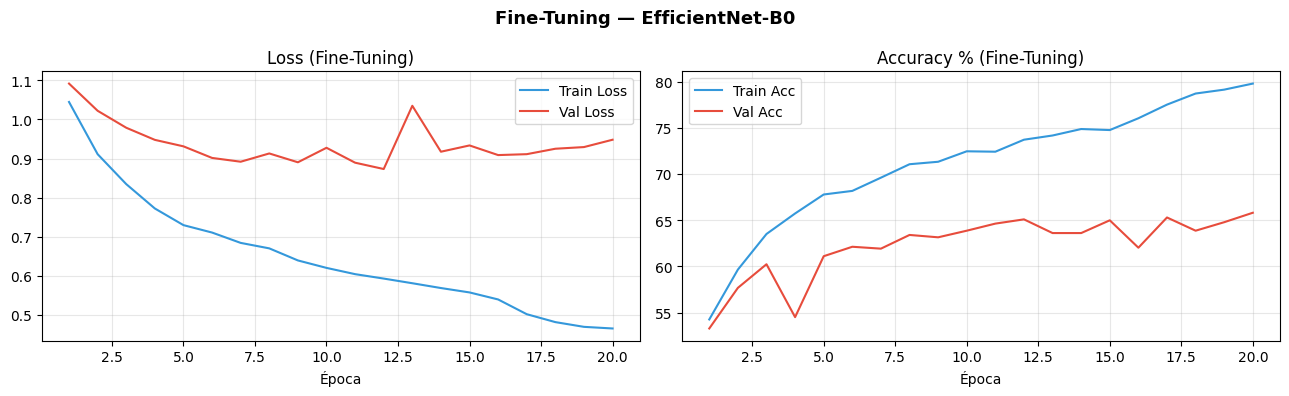


✅ Ahora ejecuta la Celda 6 para evaluar el modelo en TEST


In [11]:
# ─────────────────────────────────────────────────────────────
# CELDA 5B — Fine-Tuning: descongelar capas del backbone
# ─────────────────────────────────────────────────────────────

print("🔓 Iniciando Fine-Tuning de EfficientNet-B0...")
print("─" * 50)

# Descongelar las últimas capas del backbone
for name, param in cnn_model.named_parameters():
    if any(layer in name for layer in ['features.6', 'features.7', 'features.8', 'classifier']):
        param.requires_grad = True

trainable_ft = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"   Parámetros entrenables ahora: {trainable_ft:,}")

# Optimizador con dos learning rates distintos
optimizer_ft = optim.AdamW([
    {'params': [p for n,p in cnn_model.named_parameters()
                if any(l in n for l in ['features.6','features.7','features.8'])
                and p.requires_grad],
     'lr': 1e-4},   # lr bajo para capas preentrenadas
    {'params': cnn_model.classifier.parameters(),
     'lr': 1e-3}    # lr normal para el clasificador
], weight_decay=1e-4)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='max',
                                                      factor=0.5, patience=3)

NUM_EPOCHS_FT = 20
best_model_path = '/content/best_cnn_model.pth'
ft_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
t0_ft = time.time()

print(f"   Entrenando {NUM_EPOCHS_FT} épocas de fine-tuning...")

for epoch in range(NUM_EPOCHS_FT):
    # TRAIN
    cnn_model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_ft.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # VALIDACIÓN
    cnn_model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = cnn_model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    t_acc = train_correct / len(train_dataset)
    v_acc = val_correct   / len(val_dataset)
    t_loss = train_loss   / len(train_dataset)
    v_loss = val_loss     / len(val_dataset)

    ft_history['train_acc'].append(t_acc)
    ft_history['val_acc'].append(v_acc)
    ft_history['train_loss'].append(t_loss)
    ft_history['val_loss'].append(v_loss)

    scheduler_ft.step(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(cnn_model.state_dict(), best_model_path)

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"   Época {epoch+1:>3}/{NUM_EPOCHS_FT} | "
              f"Loss: {t_loss:.4f}/{v_loss:.4f} | "
              f"Acc: {t_acc*100:.2f}%/{v_acc*100:.2f}%")

ft_time = time.time() - t0_ft
cnn_time += ft_time  # sumar al tiempo total

print(f"\n   ✅ Fine-tuning completado: {ft_time/60:.1f} min")
print(f"   Mejor Val Accuracy total: {best_val_acc*100:.2f}%")

# Curvas del fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Fine-Tuning — EfficientNet-B0', fontsize=13, fontweight='bold')
epochs_x = range(1, NUM_EPOCHS_FT+1)

axes[0].plot(epochs_x, ft_history['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(epochs_x, ft_history['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_title('Loss (Fine-Tuning)')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in ft_history['train_acc']], label='Train Acc', color='#3498db')
axes[1].plot(epochs_x, [a*100 for a in ft_history['val_acc']],   label='Val Acc',   color='#e74c3c')
axes[1].set_title('Accuracy % (Fine-Tuning)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/07b_cnn_finetuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Ahora ejecuta la Celda 6 para evaluar el modelo en TEST")

Fine-Tuning 2: más regularización para reducir overfitting

🔧 Fine-Tuning 2 — reduciendo overfitting...
──────────────────────────────────────────────────
   Entrenando 20 épocas...
   💾 Nuevo mejor modelo guardado: Val Acc = 66.00%
   Época   1/20 | Loss: 0.6544/0.8720 | Acc: 73.09%/66.00%
   💾 Nuevo mejor modelo guardado: Val Acc = 67.48%
   Época   5/20 | Loss: 0.4812/0.9359 | Acc: 78.83%/66.05%
   Época  10/20 | Loss: 0.4282/1.0001 | Acc: 81.19%/63.96%
   Época  15/20 | Loss: 0.3956/1.0107 | Acc: 82.68%/64.62%
   Época  20/20 | Loss: 0.3787/1.0087 | Acc: 83.72%/65.34%

   ✅ Fine-Tuning 2 completado: 31.5 min
   Mejor Val Accuracy total: 67.48%


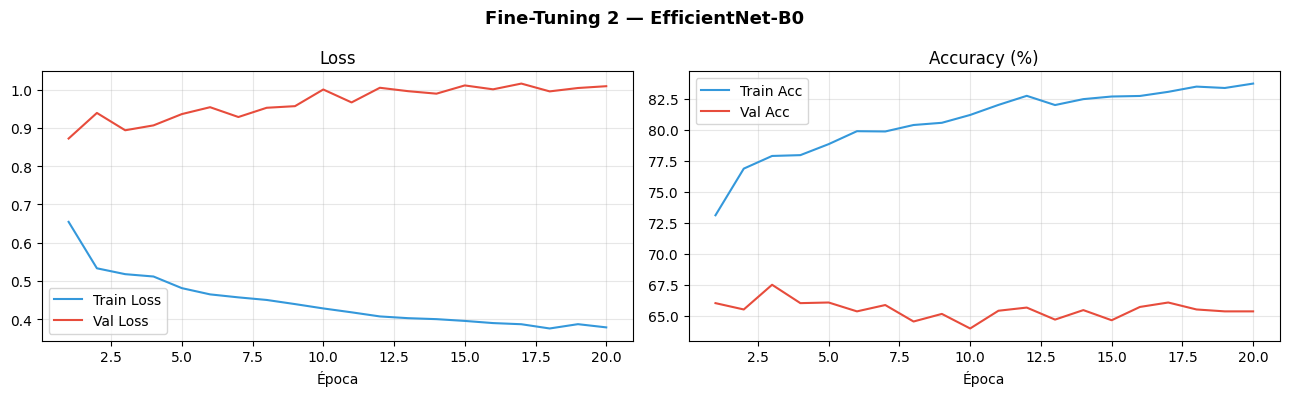


✅ Ahora sí ejecuta la Celda 6 para evaluar en TEST


In [12]:
# ─────────────────────────────────────────────────────────────
# CELDA 5C — Fine-Tuning 2: más regularización para reducir overfitting
# ─────────────────────────────────────────────────────────────

print("🔧 Fine-Tuning 2 — reduciendo overfitting...")
print("─" * 50)

# Reemplazar clasificador con más dropout
in_features = 1280
cnn_model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),       # más dropout que antes (era 0.3)
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.4),       # más dropout (era 0.2)
    nn.Linear(256, NUM_CLASSES)
)
cnn_model = cnn_model.to(DEVICE)

# Learning rate más bajo
optimizer_ft2 = optim.AdamW([
    {'params': [p for n,p in cnn_model.named_parameters()
                if any(l in n for l in ['features.6','features.7','features.8'])
                and p.requires_grad],
     'lr': 5e-5},   # más bajo que antes
    {'params': cnn_model.classifier.parameters(),
     'lr': 5e-4}
], weight_decay=1e-3)   # más weight decay

scheduler_ft2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft2, T_max=20, eta_min=1e-6
)

NUM_EPOCHS_FT2 = 20
best_val_acc2  = 0.0
ft2_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
t0_ft2 = time.time()

print(f"   Entrenando {NUM_EPOCHS_FT2} épocas...")

for epoch in range(NUM_EPOCHS_FT2):
    cnn_model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_ft2.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft2.step()
        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    cnn_model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = cnn_model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    t_acc  = train_correct / len(train_dataset)
    v_acc  = val_correct   / len(val_dataset)
    t_loss = train_loss    / len(train_dataset)
    v_loss = val_loss      / len(val_dataset)

    ft2_history['train_acc'].append(t_acc)
    ft2_history['val_acc'].append(v_acc)
    ft2_history['train_loss'].append(t_loss)
    ft2_history['val_loss'].append(v_loss)

    scheduler_ft2.step()

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(cnn_model.state_dict(), best_model_path)
        print(f"   💾 Nuevo mejor modelo guardado: Val Acc = {v_acc*100:.2f}%")

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"   Época {epoch+1:>3}/{NUM_EPOCHS_FT2} | "
              f"Loss: {t_loss:.4f}/{v_loss:.4f} | "
              f"Acc: {t_acc*100:.2f}%/{v_acc*100:.2f}%")

ft2_time = time.time() - t0_ft2
cnn_time += ft2_time

print(f"\n   ✅ Fine-Tuning 2 completado: {ft2_time/60:.1f} min")
print(f"   Mejor Val Accuracy total: {best_val_acc*100:.2f}%")

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Fine-Tuning 2 — EfficientNet-B0', fontsize=13, fontweight='bold')
epochs_x = range(1, NUM_EPOCHS_FT2+1)

axes[0].plot(epochs_x, ft2_history['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(epochs_x, ft2_history['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in ft2_history['train_acc']], label='Train Acc', color='#3498db')
axes[1].plot(epochs_x, [a*100 for a in ft2_history['val_acc']],   label='Val Acc',   color='#e74c3c')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/07c_cnn_finetuning2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Ahora sí ejecuta la Celda 6 para evaluar en TEST")

Evaluación del CNN en TEST


  📊 MÉTRICAS — CNN EfficientNet-B0
  Accuracy  : 0.6578  (65.78%)
  Precision : 0.6432
  Recall    : 0.6578
  F1-Score  : 0.6444
  AUC (OvR) : 0.8542

              precision    recall  f1-score   support

  KL0 Normal       0.70      0.82      0.76       386
KL1 Doubtful       0.38      0.24      0.29       177
    KL2 Mild       0.59      0.65      0.62       258
KL3 Moderate       0.85      0.71      0.78       129
  KL4 Severe       1.00      0.86      0.93        29

    accuracy                           0.66       979
   macro avg       0.71      0.66      0.67       979
weighted avg       0.64      0.66      0.64       979



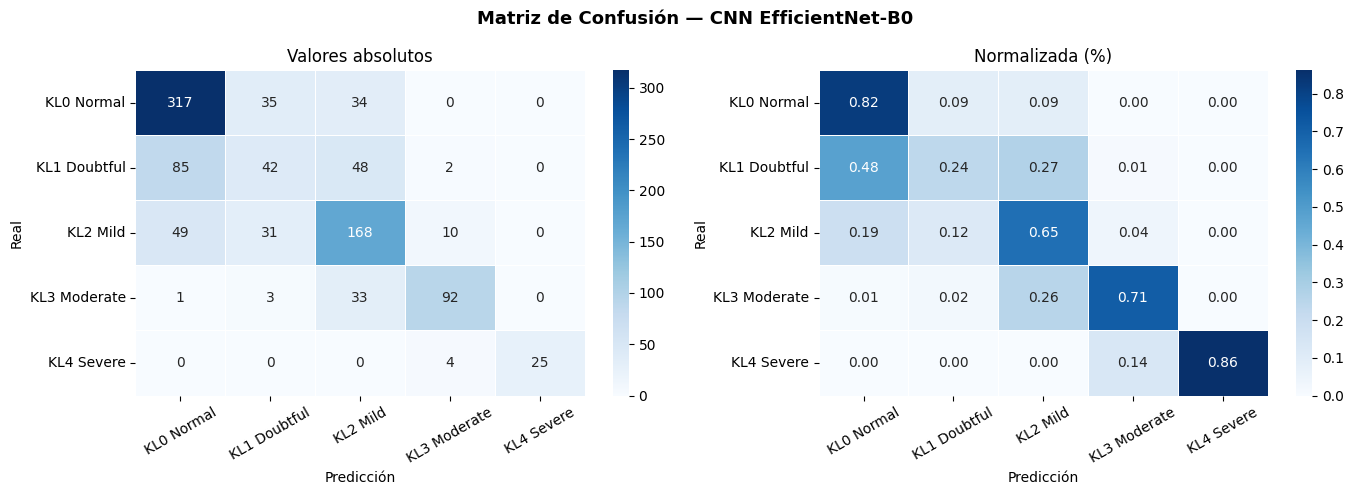

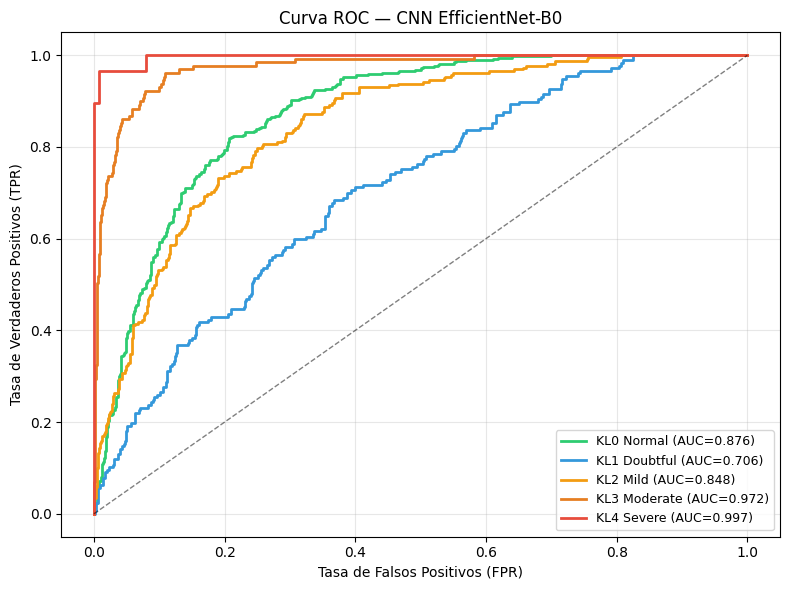

In [13]:
# Cargar mejor modelo
cnn_model.load_state_dict(torch.load(best_model_path))
cnn_model.eval()

y_true_cnn, y_pred_cnn, y_prob_cnn = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = cnn_model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(1).cpu().numpy()
        y_true_cnn.extend(labels.numpy())
        y_pred_cnn.extend(preds)
        y_prob_cnn.extend(probs)

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)
y_prob_cnn = np.array(y_prob_cnn)

metricas_cnn = calcular_metricas(y_true_cnn, y_pred_cnn, y_prob_cnn,
                                   'CNN EfficientNet-B0')
metricas_cnn['tiempo_entrenamiento'] = cnn_time

graficar_confusion(y_true_cnn, y_pred_cnn,
                   'CNN EfficientNet-B0',
                   '/content/08_cnn_confusion.png')

graficar_roc(y_true_cnn, y_prob_cnn,
             'CNN EfficientNet-B0',
             '/content/09_cnn_roc.png')
